# Electricity consumption given weather 
To get the data, unzip the zip file in this subdir, I can't push it to github and I have shot myself in the foot several times trying to. 
This is more or less a stress test, the data is not super difficult, but in its current sampling it just has a lot of points.

In [44]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import gpflow as gpf 
import numpy as np
import tensorflow as tf
np.random.seed(42)
tf.random.set_seed(42)
import scipy.stats as ss
from tslearn.metrics import dtw

import matplotlib.pyplot as plt 
import tqdm as tqdm
import os

import sys
sys.path.append("../..")

from atmodel import ConditionalMOGP, SparseCMOGP
from atlikelihood import TransferLikelihood
from robust_svgp import LMCInducingPointsBase

def safe_float_conversion(v):
    try:
        v = float(v)
        return v
    except ValueError:
        return np.nan


ihepc = pd.read_csv("household_power_consumption.txt", sep=";", low_memory=False)
ihepc["Datetime"] = ihepc["Date"] + " "+ ihepc["Time"]
ihepc["Datetime"] = pd.to_datetime(ihepc["Datetime"])
ihepc.index = ihepc.Datetime
ihepc_weekly = ihepc["Global_active_power"].map(safe_float_conversion).resample("2W").mean().bfill()
power_weekly = (ihepc_weekly - ihepc_weekly.mean()) / ihepc_weekly.std()

/tmp/ipykernel_11505/253766856.py:33: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  ihepc["Datetime"] = pd.to_datetime(ihepc["Datetime"])


In [ ]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(14, 4))
    Xtest = np.linspace(0, 1, 100)[:, None]
    plt.plot(Ax, Ay, "x", color="C0", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, "C0", "Y1")

    plt.plot(Bx, By, "x", color="C1", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, "C1", "Y2")
    plt.xlim([0, Ax[:,0].max()])
    plt.ylim([-5, 5])
    try:
        ivs = m.inducing_variable.Z.numpy() 
        plt.scatter(ivs, np.zeros_like(ivs)+2, marker="|", c=m.inducing_indices)
    except AttributeError:
        pass
    plt.legend()
    return mu


def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()
 

In [46]:
weather = pd.read_csv("export.csv")
weather["date"] = pd.to_datetime(weather["date"])
weather.head()
weather.index = weather.date
weather_daily = weather.tavg.bfill().resample("D").mean()
weather_daily = (weather_daily - weather_daily.mean())/weather_daily.std()

104 1461


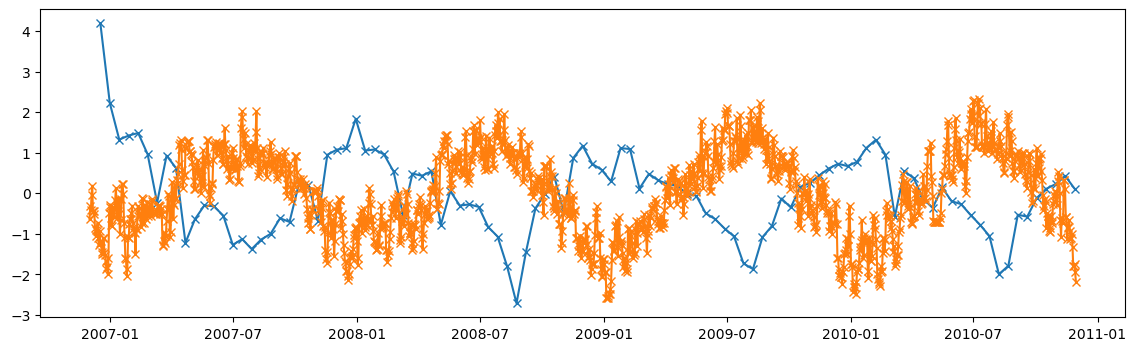

In [55]:
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
print(len(ihepc_weekly), len(weather_daily))
plt.plot(power_weekly, color="C0", marker="x")
plt.plot(weather_daily, color="C1", marker="x")
plt.show()

(104, 1) (104, 1)
(100, 1) (100, 1)
4 4
(1461, 1) (1461, 1) (100, 1) (100, 1)


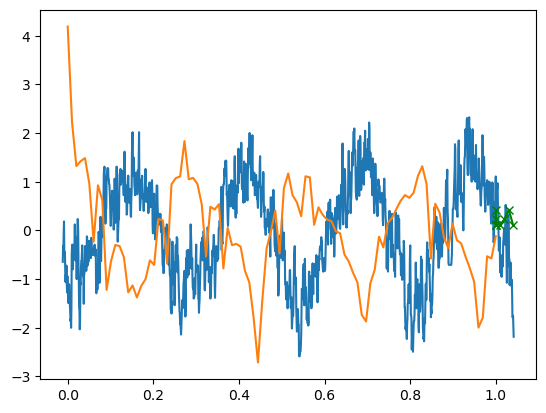

In [60]:
Bx = power_weekly.index.view("int64").reshape(-1, 1).astype(float)
By = power_weekly.values.reshape(-1, 1).astype(np.float64)
Ax = weather_daily.index.view("int64").reshape(-1, 1).astype(float)
Ay = weather_daily.values.reshape(-1, 1).astype(np.float64)
n_test = 4
Xtest, ytest = Bx[-n_test:], By[-n_test:]
print(Bx.shape, By.shape)
Bx, By = Bx[:-n_test,:], By[:-n_test,:]
print(Bx.shape, By.shape)
print(len(Xtest), len(ytest))
Xtest = (Xtest - Bx.min()) /(Bx.max() - Bx.min())
Ax = (Ax - Bx.min()) /(Bx.max() - Bx.min())
Bx = (Bx - Bx.min()) /(Bx.max() - Bx.min())
print(Ax.shape, Ay.shape, Bx.shape, By.shape)

X = np.vstack((np.hstack((Ax, np.zeros_like(Ax, dtype=np.int32))), np.hstack((Bx, np.ones_like(Bx, dtype=np.int32)))))
y = np.vstack((np.hstack((Ay, np.zeros_like(Ay, dtype=np.int32))), np.hstack((By, np.ones_like(By, dtype=np.int32)))))
Xtest = np.hstack((Xtest, np.ones_like(Xtest)))

plt.plot(Ax, Ay)
plt.plot(Bx, By)
plt.plot(Xtest, ytest, marker="x", color="green")
plt.show()

### CMOGP, takes about 1 minute with 20 ivs (100 is already much better, that takes 5 minutes or so) 

tf.Tensor(-144.6127819868715, shape=(), dtype=float64)
╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────

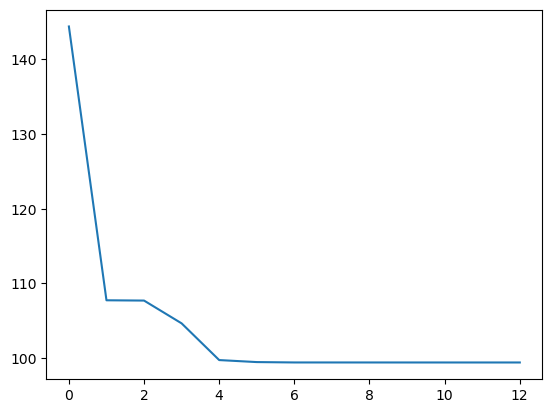

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value               │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.04923             │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.0761429724231133  │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────

In [62]:
output_dim = 2 # Number of outputs
k = gpf.kernels.Matern32()
#k = gpf.kernels.Periodic(gpf.kernels.Matern32())
# Base kernel

# Coregion kernel
coreg1 = gpf.kernels.Coregion(output_dim=output_dim, rank=1, active_dims=[1])
ivs = np.linspace(0, max(Xtest[:,0]), 100).reshape(-1, 1)
iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
shuffle = np.random.permutation(np.arange(len(ivs)))
iv_ind = iv_ind[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg1
m = SparseCMOGP((X, y), exact_target=False, kernel=kern, jitter=1e-3, inducing_variable=LMCInducingPointsBase(ivs), likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))

print(m.maximum_log_likelihood_objective())

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)


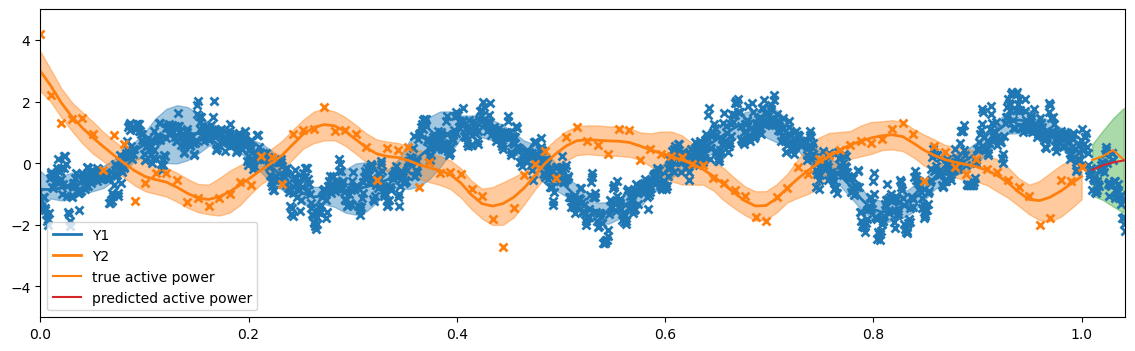

0.08793152986303857


In [63]:
plot(m)
mu2, var2 = m.predict_f(Xtest)
plt.plot(Xtest[:,0], ytest, color="C1", label="true active power")
plt.plot(Xtest[:,0], mu2, color="C3", label="predicted active power")
plt.fill_between(
        Xtest[:, 0],
        (mu2 - 2 * np.sqrt(var2))[:, 0],
        (mu2 + 2 * np.sqrt(var2))[:, 0],
        color="C2",
        alpha=0.4,
    )
plt.legend()
plt.show()
print(np.mean((mu2 - ytest)**2))


### Comparison to VGP (takes 10 minutes on my machine)

In [52]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W
from robust_svgp import LMCInducingPointsBase

# Base kernel
k = gpf.kernels.Periodic(gpf.kernels.Matern32())
k = gpf.kernels.Matern32()


# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

ivs = np.linspace(0, max(Xtest[:,0]), 100).reshape(-1, 1)
iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
iv_ind = iv_ind[shuffle]
ivs = np.hstack((ivs, iv_ind))

lik = gpf.likelihoods.SwitchedLikelihood(
    [gpf.likelihoods.Gaussian(), gpf.likelihoods.Gaussian()]
)
kern = k * coreg
# now build the GP model as normal
m = gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=LMCInducingPointsBase(ivs))
# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss_closure((X, y)),
    m.trainable_variables,
    method="L-BFGS-B",
)

2026-09-21 18:08:28.085236: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-09-21 18:08:28.124311: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 1111.6756030259603
        x: [ 1.561e+00 -1.874e+00 ... -1.452e+00 -1.371e+00]
      nit: 421
      jac: [-2.742e-03 -3.269e-03 ...  6.096e-04  1.270e-03]
     nfev: 461
     njev: 461
 hess_inv: <5158x5158 LbfgsInvHessProduct with dtype=float64>

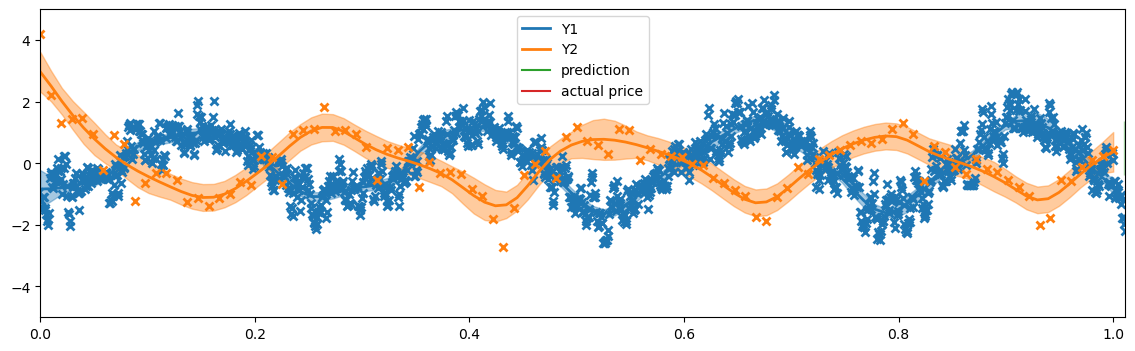

0.15728248085427815


In [54]:
plot(m)
mu, var = m.predict_f(Xtest)
plt.plot(Xtest[:,0], mu)
plt.plot(Xtest[:,0], ytest)
plt.plot(Xtest[:,0], mu, label="prediction")
plt.plot(Xtest[:,0], ytest, label="actual price")
plt.fill_between(
        Xtest[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color="C2",
        alpha=0.4,
    )
plt.legend()
plt.show()
print(np.mean((mu - ytest)**2))